# Analisis Time Series Univariat

## Import Library

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

## Import Data

In [4]:
# Download data saham Telkom (induk Telkomsel)
data = yf.download("TLKM.JK", start="2018-01-01", end="2024-12-31")

# Ambil variabel (multivariat untuk VAR)
data = data[['Close', 'Volume']]

# Hapus missing value
data = data.dropna()

# Tampilkan data
print(data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close     Volume
Ticker          TLKM.JK    TLKM.JK
Date                              
2018-01-01  2982.616455          0
2018-01-02  2962.463623   66075600
2018-01-03  2841.546631  129205000
2018-01-04  2834.829346   77953300
2018-01-05  2875.135010   55863000


In [5]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

Jumlah missing values per kolom:
Price   Ticker 
Close   TLKM.JK    0
Volume  TLKM.JK    0
dtype: int64


In [6]:
# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)

Jumlah nilai NaN per kolom:
Price   Ticker 
Close   TLKM.JK    0
Volume  TLKM.JK    0
dtype: int64


## Visualisasi Data Awal

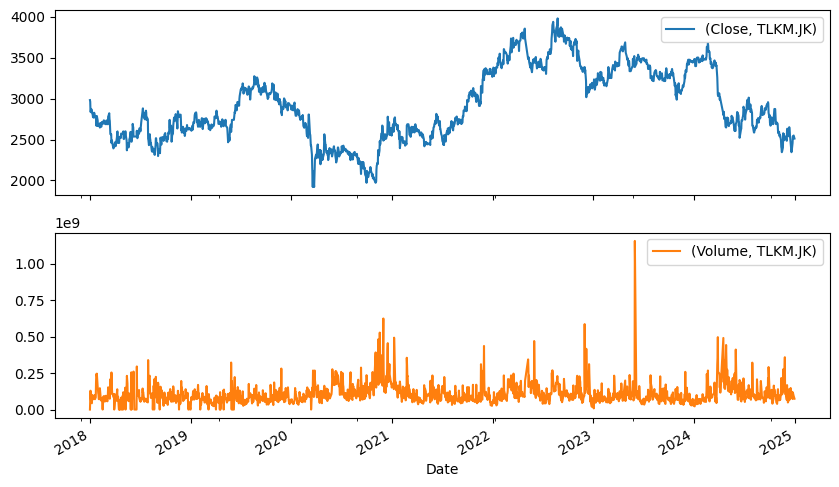

In [7]:
data.plot(subplots=True, figsize=(10,6))
plt.show()

## Uji Stasioneritas (ADF Test)

In [8]:
# Uji ADF
result = adfuller(data['Close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Cek Hipotesis
if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")

ADF Statistic: -2.112967
p-value: 0.239333
Data tidak stasioner, lakukan differencing.


## Lakukan Differencing

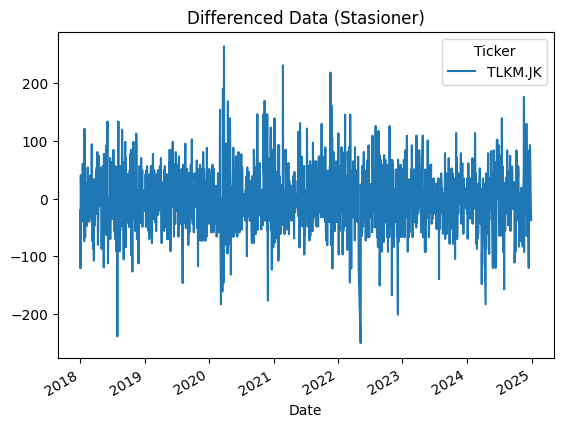

p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


In [9]:
# Lakukan Differencing jika data tidak stasioner
data_diff = data['Close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")
plt.show()

# Uji ADF lagi setelah differencing
result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])

# Cek Hipotesis
if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")

In [10]:
# Cek apakah ada missing value
missing_values = data_diff.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data_diff.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)

Jumlah missing values per kolom:
Ticker
TLKM.JK    0
dtype: int64
Jumlah nilai NaN per kolom:
Ticker
TLKM.JK    0
dtype: int64


## Cek Autocorrelation (ACF) dan Partial Autocorrelation (PACF)

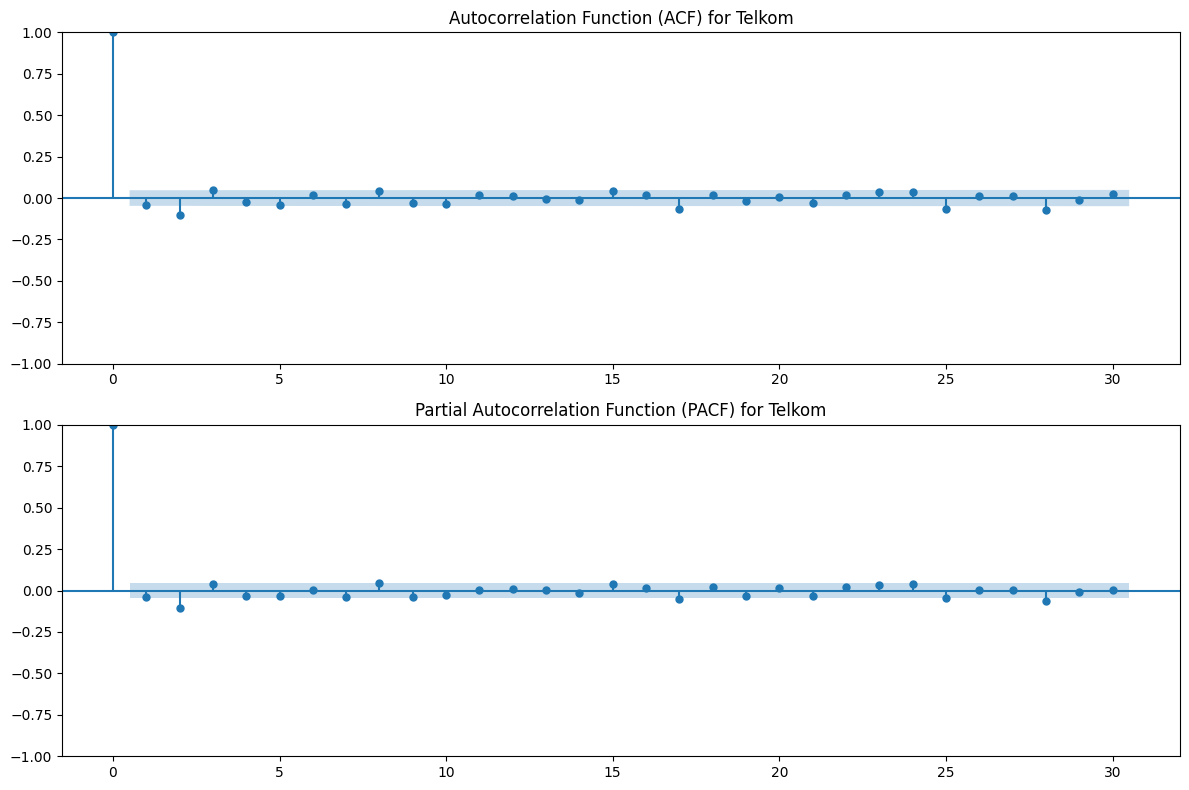

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for Telkom')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for Telkom')

plt.tight_layout()
plt.show()

## Model ARIMA

In [12]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                TLKM.JK   No. Observations:                 1729
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9230.953
Date:                Sun, 19 Apr 2026   AIC                          18467.905
Time:                        17:46:00   BIC                          18484.270
Sample:                             0   HQIC                         18473.958
                               - 1729                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6708      0.122      5.496      0.000       0.432       0.910
ma.L1         -0.7324      0.110     -6.672      0.000      -0.948      -0.517
sigma2      2555.7634     61.628     41.471      0.0

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## Forecasting

In [13]:
forecast = model_fit.forecast(steps=10)

print(forecast)

1729    2510.489686
1730    2509.385286
1731    2508.644412
1732    2508.147405
1733    2507.813994
1734    2507.590330
1735    2507.440287
1736    2507.339632
1737    2507.272109
1738    2507.226813
Name: predicted_mean, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


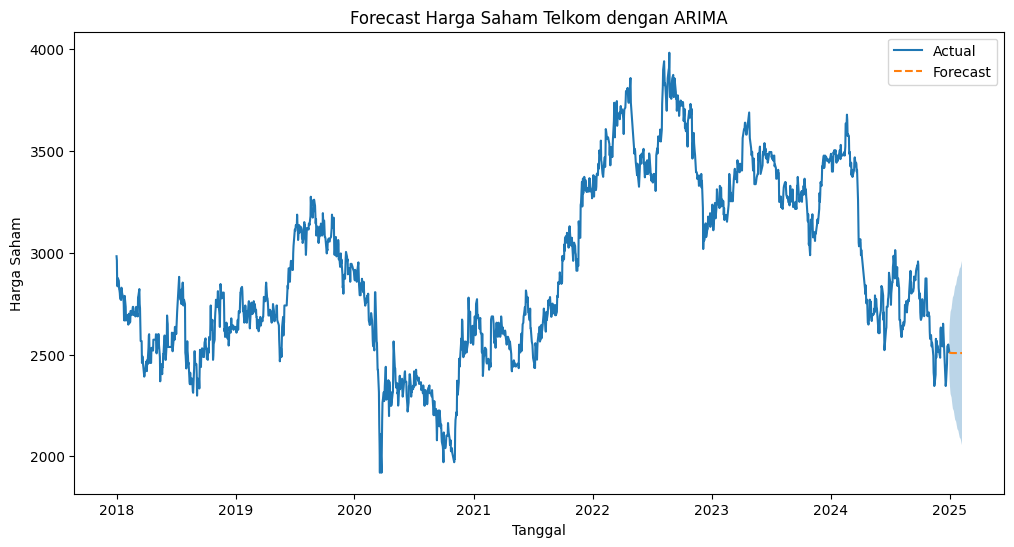

In [14]:
import matplotlib.pyplot as plt

# Forecast + confidence interval
forecast_result = model_fit.get_forecast(steps=30)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Index waktu untuk forecast
forecast_index = pd.date_range(start=data.index[-1], periods=30, freq='B')

# Plot
plt.figure(figsize=(12,6))

# Data asli
plt.plot(data.index, data['Close'], label='Actual')

# Forecast
plt.plot(forecast_index, forecast, label='Forecast', linestyle='dashed')

# Confidence interval (area bayangan)
plt.fill_between(forecast_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 alpha=0.3)

plt.title('Forecast Harga Saham Telkom dengan ARIMA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham')
plt.legend()

plt.show()

# Analisis Time Series Multivariat

[*********************100%***********************]  2 of 2 completed

                   TLKM         BBCA
Date                                
2020-01-02  2864.556396  5540.171875
2020-01-03  2915.839844  5631.266113
2020-01-06  2901.187500  5577.437988
2020-01-07  2886.534912  5581.578125
2020-01-08  2857.230225  5531.890625
ADF Statistic: -1.1811861774703563
p-value: 0.6816361349751734
Data tidak stasioner, lakukan differencing.
ADF Statistic: -0.7549501525927816
p-value: 0.8319984158629403
Data tidak stasioner, lakukan differencing.
Differencing dilakukan untuk TLKM.
Differencing dilakukan untuk BBCA.


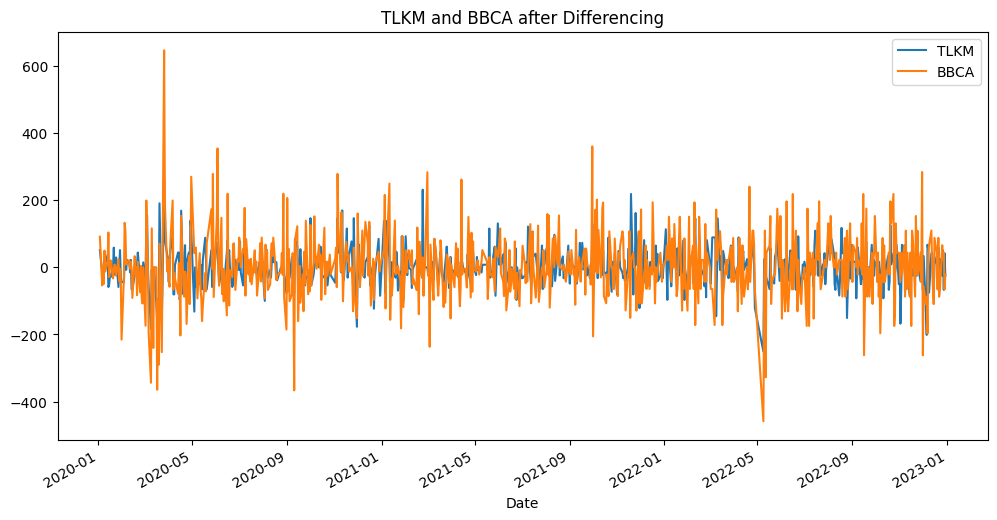

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   TLKM   No. Observations:                  734
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3992.564
Date:                Sun, 19 Apr 2026   AIC                           7991.128
Time:                        17:56:26   BIC                           8004.919
Sample:                             0   HQIC                          7996.447
                                - 734                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0683      0.030     -2.266      0.023      -0.127      -0.009
ma.L1         -0.9984      0.009   -111.636      0.000      -1.016      -0.981
sigma2      3124.0907    110.325     28.317      0.0

In [20]:
# Import libraries yang diperlukan
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Ambil data harga penutupan untuk TLKM dan BBCA
tickers = ['TLKM.JK', 'BBCA.JK']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01', group_by='ticker')

# Ambil hanya harga penutupan
data_combined = pd.DataFrame({
    'TLKM': data['TLKM.JK']['Close'],
    'BBCA': data['BBCA.JK']['Close']
})

# Tampilkan beberapa baris data
print(data_combined.head())

# Fungsi untuk memeriksa stasionaritas
def check_stationarity(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] < 0.05:
        print("Data stasioner, lanjutkan analisis.")
        return True
    else:
        print("Data tidak stasioner, lakukan differencing.")
        return False

# Cek stasionaritas
is_stationary_tlkm = check_stationarity(data_combined['TLKM'])
is_stationary_bbca = check_stationarity(data_combined['BBCA'])

# Differencing jika perlu
if not is_stationary_tlkm:
    data_combined['TLKM'] = data_combined['TLKM'].diff()
    print("Differencing dilakukan untuk TLKM.")

if not is_stationary_bbca:
    data_combined['BBCA'] = data_combined['BBCA'].diff()
    print("Differencing dilakukan untuk BBCA.")

# Hapus NaN
data_combined = data_combined.dropna()

# Visualisasi
data_combined.plot(figsize=(12, 6), title='TLKM and BBCA after Differencing')
plt.show()

# Contoh ARIMA (misalnya untuk TLKM)
model = ARIMA(data_combined['TLKM'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

In [21]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Ambil data
tickers = ['TLKM.JK', 'BBCA.JK']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01')

# Ambil harga penutupan
data_combined = pd.DataFrame({
    'TLKM': data['Close']['TLKM.JK'],
    'BBCA': data['Close']['BBCA.JK']
})

# Hapus NaN
data_combined = data_combined.dropna()

# Fungsi cek stasioneritas
def check_stationarity(series):
    result = adfuller(series)
    return result[1] < 0.05  # True kalau stasioner

# Differencing jika perlu
for col in data_combined.columns:
    if not check_stationarity(data_combined[col]):
        data_combined[col] = data_combined[col].diff()

# Drop NaN setelah differencing
data_combined = data_combined.dropna()

# ======================
# MODEL VAR
# ======================

# Tentukan lag optimal
model = VAR(data_combined)
lag_order = model.select_order(maxlags=15)
print(lag_order.summary())

# Ambil lag terbaik (AIC)
optimal_lag = lag_order.selected_orders['aic']
print("Lag optimal:", optimal_lag)

# Fit model
var_model = model.fit(optimal_lag)

# Summary
print(var_model.summary())

[*********************100%***********************]  2 of 2 completed

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        17.07      17.08*   2.586e+07       17.07
1        17.05       17.09   2.531e+07       17.06
2       17.03*       17.09  2.478e+07*      17.05*
3        17.03       17.12   2.484e+07       17.06
4        17.04       17.15   2.508e+07       17.08
5        17.05       17.19   2.531e+07       17.10
6        17.06       17.22   2.556e+07       17.12
7        17.06       17.25   2.572e+07       17.14
8        17.07       17.28   2.578e+07       17.15
9        17.07       17.31   2.584e+07       17.16
10       17.07       17.34   2.588e+07       17.17
11       17.07       17.37   2.596e+07       17.19
12       17.07       17.39   2.594e+07       17.19
13       17.08       17.42   2.619e+07       17.21
14       17.08       17.45   2.628e+07       17.23
15       17.09       17.48   2.639e+07       17.24
-------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
